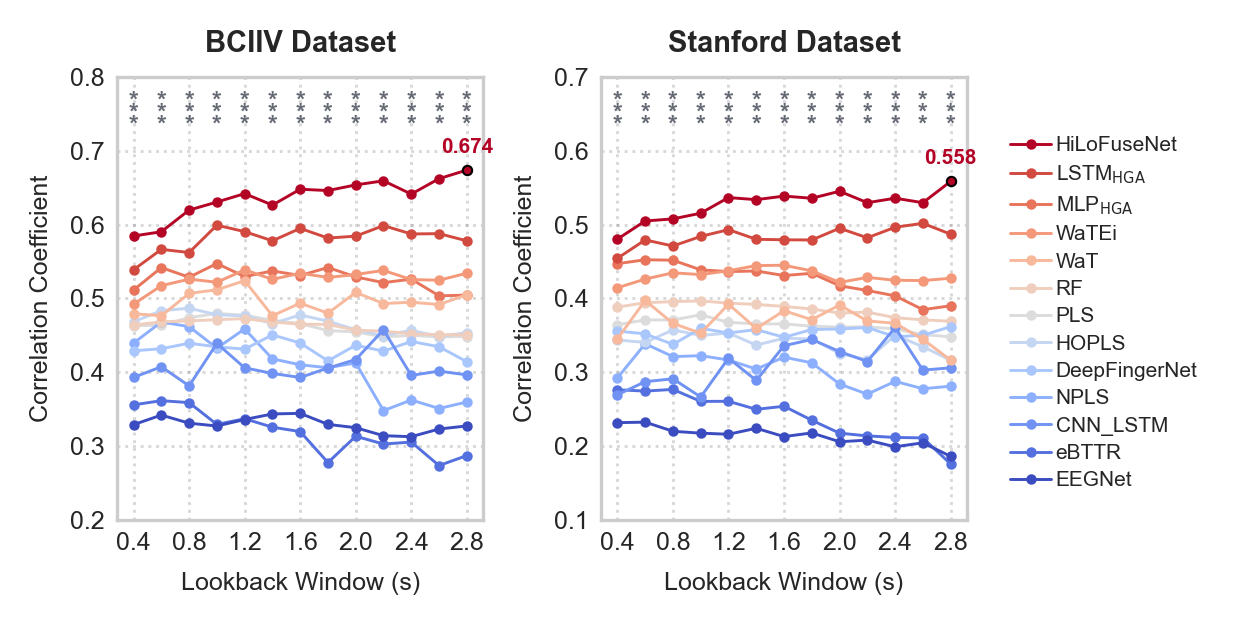

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from statsmodels.stats.multitest import multipletests
from scipy.stats import friedmanchisquare

seed = 42
win_sizes = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8]

dataset_configs = {
    'BCIIV': ['sub1', 'sub2', 'sub3'],
    'Stanford': ['bp', 'cc', 'ht', 'jc', 'jp', 'mv', 'wc', 'wm', 'zt']
}

trad_decoders = ['PLS', 'NPLS', 'HOPLS', 'eBTTR', 'RF']
nn_decoders = ['MLP', 'LSTM', 'EEGNet', 'DeepFingerNet', 'CNN_LSTM', 'WaT', 'WaTEi', 'HiLoFuseNet']
all_decoders = trad_decoders + nn_decoders
target_model = 'HiLoFuseNet'

nn_decoders_rename = [r"MLP$_{\text{HGA}}$", r"LSTM$_{\text{HGA}}$", 'EEGNet', 'DeepFingerNet', 'CNN_LSTM', 'WaT',
                      'WaTEi', 'HiLoFuseNet']
rename_map = {old: new for old, new in zip(nn_decoders, nn_decoders_rename)}
for trad in trad_decoders: rename_map[trad] = trad

markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X', '<', '>', 'd', 'P']

# load data
win_model_subject_matrix = {w: {d: [] for d in all_decoders} for w in win_sizes}
for win_size in win_sizes:
    for decoder in all_decoders:
        for dataset_name, subject_list in dataset_configs.items():

            if decoder in nn_decoders:
                # load DNN results
                file_path = f'results/o5/varyingWindow/{dataset_name}_{decoder}_mse_seed{seed}_win{win_size}_O5_cc.npy'
                if os.path.exists(file_path):
                    try:
                        cc_data = np.load(file_path)  # nFinger * nSubject
                        subject_means = np.mean(cc_data, axis=0)
                        win_model_subject_matrix[win_size][decoder].extend(subject_means)
                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")
                else:
                    print(f"Warning: File not found -> {file_path}")

            else:
                # load ML results
                for sub in subject_list:
                    file_path = f'results/o5/varyingWindow/{dataset_name}_{decoder}_win{win_size}_sub_{sub}_O5_cc.npy'
                    if os.path.exists(file_path):
                        try:
                            cc_data = np.load(file_path)
                            sub_mean = np.mean(cc_data)
                            win_model_subject_matrix[win_size][decoder].append(sub_mean)
                        except Exception as e:
                            print(f"Error loading {file_path}: {e}")
                    else:
                        print(f"Warning: File not found -> {file_path}")

# Friedman test
raw_p_values = []
for win_size in win_sizes:
    samples_list = []
    for decoder in all_decoders:
        scores = win_model_subject_matrix[win_size][decoder]
        if len(scores) == 12:
            samples_list.append(scores)
    if len(samples_list) == len(all_decoders):
        _, p_val = friedmanchisquare(*samples_list)
        raw_p_values.append(p_val)
    else:
        raw_p_values.append(1.0)

# FDR correction
reject, p_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='fdr_bh')

# set color code
decoder_peak_scores = {}
for decoder in all_decoders:
    best_mean = -1
    for w in win_sizes:
        scores = win_model_subject_matrix[w][decoder]
        if len(scores) == 12:
            current_mean = np.mean(scores)
            if current_mean > best_mean:
                best_mean = current_mean
    decoder_peak_scores[decoder] = best_mean if best_mean != -1 else 0

sorted_decoders = sorted(all_decoders, key=lambda d: decoder_peak_scores[d])
cmap = plt.get_cmap('coolwarm')
decoder_colors = {d: mcolors.to_hex(cmap(i / (len(all_decoders) - 1))) for i, d in enumerate(sorted_decoders)}

# show statistical results
cm = 1 / 2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10 * cm, 5 * cm), dpi=300)

def pack_plot_data(dataset_name):
    plot_summary = {d: {"wins": [], "r_means": []} for d in all_decoders}
    for w in win_sizes:
        for d in all_decoders:
            scores = win_model_subject_matrix[w][d]
            sub_scores = scores[:3] if dataset_name == 'BCIIV' else scores[3:]
            if sub_scores:
                plot_summary[d]["wins"].append(w)
                plot_summary[d]["r_means"].append(np.mean(sub_scores))
    return plot_summary

results_bciiv = pack_plot_data('BCIIV')
results_stanford = pack_plot_data('Stanford')

for idx, decoder in enumerate(all_decoders):
    current_linewidth = 0.7 if decoder == target_model else 0.7
    current_marker = markers[0]
    current_color = decoder_colors[decoder]
    display_name = rename_map[decoder]

    # left figure: BCIIV
    d_b = results_bciiv[decoder]
    if d_b["wins"]:
        ax1.plot(d_b["wins"], d_b["r_means"], marker=current_marker, color=current_color,
                 linewidth=current_linewidth, markersize=1.5, label=display_name)

    # right figure: Stanford
    d_s = results_stanford[decoder]
    if d_s["wins"]:
        ax2.plot(d_s["wins"], d_s["r_means"], marker=current_marker, color=current_color,
                 linewidth=current_linewidth, markersize=1.5)

def apply_style(ax, title, ylabel, ylims):
    ax.set_title(title, fontsize=7, fontweight='bold', pad=6)
    ax.set_ylim(ylims)
    ax.set_xlabel('Lookback Window (s)', fontsize=6)
    ax.set_ylabel(ylabel, fontsize=6)
    ax.set_xticks(win_sizes[::2])
    ax.tick_params(axis='both', labelsize=6, pad=3, length=0)
    ax.grid(True, which='major', linestyle=':', linewidth=0.7, color='gray', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(0.8)

apply_style(ax1, 'BCIIV Dataset', 'Correlation Coefficient', (0.2, 0.8))
apply_style(ax2, 'Stanford Dataset', 'Correlation Coefficient', (0.1, 0.7))

# add asterisks
hilo_color = decoder_colors[target_model]
for idx, win_size in enumerate(win_sizes):
    if reject[idx]:
        p_corr = p_corrected[idx]

        if p_corr < 0.001:
            mark = '*\n*\n*'
        elif p_corr < 0.01:
            mark = '*\n*'
        else:
            mark = '*'

        ax1.text(win_size, 0.75, mark,
                 ha='center',
                 va='center',
                 color='#646973',
                 fontsize=6,
                 fontweight='bold',
                 linespacing=0.4)

        ax2.text(win_size, 0.65, mark,
                 ha='center',
                 va='center',
                 color='#646973',
                 fontsize=6,
                 fontweight='bold',
                 linespacing=0.4)

# show the overall best
for ax, res_data, max_y_edge in zip([ax1, ax2], [results_bciiv, results_stanford], [0.8, 0.7]):
    hilo_data = res_data[target_model]
    if hilo_data["wins"]:
        wins, r_vals = np.array(hilo_data["wins"]), np.array(hilo_data["r_means"])
        m_idx = np.argmax(r_vals)
        max_x, max_y = wins[m_idx], r_vals[m_idx]
        ax.scatter(max_x, max_y, color=hilo_color, s=5, edgecolors='black', linewidths=0.5, zorder=5)

        offset_y = -8 if max_y > (max_y_edge - 0.08) else 5
        va_dir = 'top' if offset_y < 0 else 'bottom'
        ax.annotate(f'{max_y:.3f}', xy=(max_x, max_y-0.01), xytext=(0, offset_y), textcoords='offset points',
                    ha='center', va=va_dir, fontsize=5, fontweight='bold', color=hilo_color)

handles, labels = ax1.get_legend_handles_labels()

sorted_decoders_descending = sorted_decoders[::-1]
ordered_labels = [rename_map[d] for d in sorted_decoders_descending]
ordered_handles = [handles[labels.index(lbl)] for lbl in ordered_labels if lbl in labels]
fig.legend(ordered_handles, ordered_labels, loc='center left', bbox_to_anchor=(0.82, 0.5),
           ncol=1, fontsize=5, frameon=False, labelspacing=0.4, handletextpad=0.2)
plt.subplots_adjust(bottom=0.15, left=0.08, right=0.8, top=0.90, wspace=0.32)

figPath = 'E:/my papers/finger decoding/HiLoFuseNet/figures/'
plt.savefig(figPath + 'overall_windowed_comparison.png', dpi=300)
plt.show()

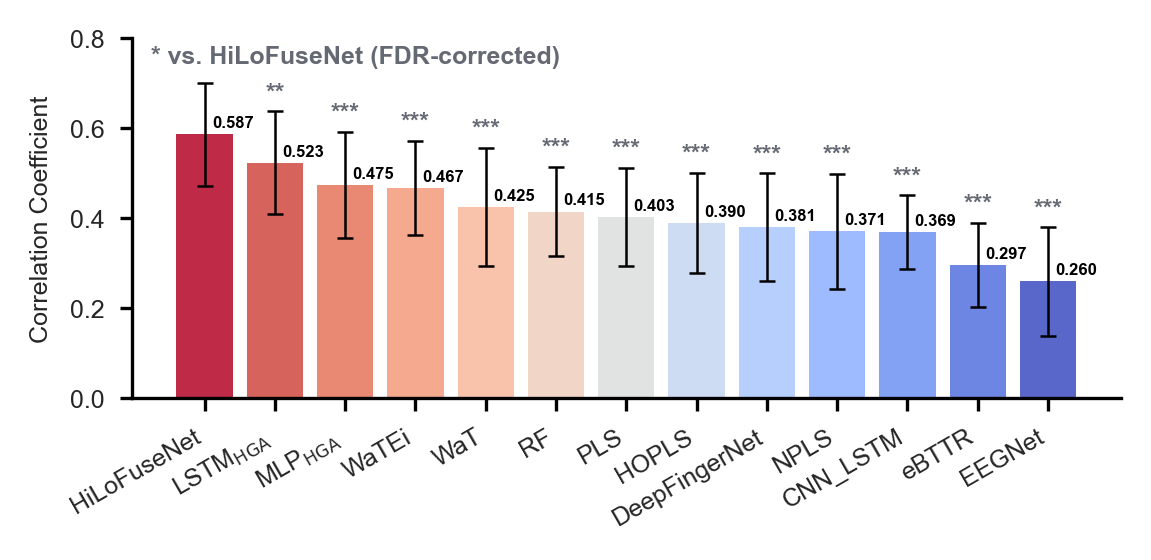

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

seed = 42
win_sizes = [0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8]

dataset_configs = {
    'BCIIV': ['sub1', 'sub2', 'sub3'],
    'Stanford': ['bp', 'cc', 'ht', 'jc', 'jp', 'mv', 'wc', 'wm', 'zt']
}

trad_decoders = ['PLS', 'NPLS', 'HOPLS', 'eBTTR', 'RF']
nn_decoders = ['MLP', 'LSTM', 'EEGNet', 'DeepFingerNet', 'CNN_LSTM', 'WaT', 'WaTEi', 'HiLoFuseNet']
all_decoders = trad_decoders + nn_decoders
target_model = 'HiLoFuseNet'

nn_decoders_rename = [r"MLP$_{\text{HGA}}$", r"LSTM$_{\text{HGA}}$", 'EEGNet', 'DeepFingerNet', 'CNN_LSTM', 'WaT','WaTEi', 'HiLoFuseNet']
rename_map = {old: new for old, new in zip(nn_decoders, nn_decoders_rename)}
for trad in trad_decoders: rename_map[trad] = trad

win_model_subject_matrix = {w: {d: [] for d in all_decoders} for w in win_sizes}
for win_size in win_sizes:
    for decoder in all_decoders:
        for dataset_name, subject_list in dataset_configs.items():
            if decoder in nn_decoders:
                file_path = f'results/o5/varyingWindow/{dataset_name}_{decoder}_mse_seed{seed}_win{win_size}_o5_cc.npy'
                if os.path.exists(file_path):
                    try:
                        cc_data = np.load(file_path)
                        subject_means = np.mean(cc_data, axis=0)
                        win_model_subject_matrix[win_size][decoder].extend(subject_means)
                    except Exception as e:
                        print(f"Error loading {file_path}: {e}")
            else:
                for sub in subject_list:
                    file_path = f'results/o5/varyingWindow/{dataset_name}_{decoder}_win{win_size}_sub_{sub}_O5_cc.npy'
                    if os.path.exists(file_path):
                        try:
                            cc_data = np.load(file_path)
                            sub_mean = np.mean(cc_data)
                            win_model_subject_matrix[win_size][decoder].append(sub_mean)
                        except Exception as e:
                            print(f"Error loading {file_path}: {e}")

# the best performance for each model
peak_results = []
for decoder in all_decoders:
    best_mean = -1
    best_std = 0
    best_pool = []
    best_win = None

    for win_size in win_sizes:
        scores = win_model_subject_matrix[win_size][decoder]
        if len(scores) == 12:
            current_mean = np.mean(scores)
            if current_mean > best_mean:
                best_mean = current_mean
                best_std = np.std(scores)
                best_pool = scores
                best_win = win_size

    peak_results.append({
        'decoder': decoder,
        'display_name': rename_map[decoder],
        'mean': best_mean if best_mean != -1 else 0,
        'std': best_std,
        'pool': best_pool,
        'best_win': best_win
    })

# sort the model for visualization
peak_results = sorted(peak_results, key=lambda x: x['mean'], reverse=True)
sorted_names = [x['display_name'] for x in peak_results]
sorted_means = [x['mean'] for x in peak_results]
sorted_stds = [x['std'] for x in peak_results]
sorted_pools = [x['pool'] for x in peak_results]
sorted_raw_names = [x['decoder'] for x in peak_results]
hilo_idx = sorted_raw_names.index(target_model)
hilo_peak_pool = sorted_pools[hilo_idx]

# statistical test
p_values = []
compare_pairs = []

for i in range(len(sorted_pools)):
    if i == hilo_idx:
        continue
    if len(sorted_pools[i]) == 12:
        _, p_val = wilcoxon(hilo_peak_pool, sorted_pools[i])
        p_values.append(p_val)
        compare_pairs.append((hilo_idx, i))

# FDR correction
if p_values:
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
else:
    p_corrected = []


cmap = plt.get_cmap('coolwarm_r')
bars_colors = [mcolors.to_hex(cmap(i / (len(peak_results) - 1))) for i in range(len(peak_results))]

cm = 1 / 2.54
fig, ax = plt.subplots(figsize=(10 * cm, 5 * cm), dpi=300)

bars = ax.bar(
    sorted_names,
    sorted_means,
    yerr=sorted_stds,
    capsize=2,
    error_kw={'elinewidth': 0.6, 'capthick': 0.6},
    zorder=1
)
for i, bar in enumerate(bars):
    bar.set_facecolor(bars_colors[i])
    bar.set_edgecolor('none')
    bar.set_alpha(0.85)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.grid(False)

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(
            bar.get_x() + bar.get_width() +0.0,
            yval + 0.008,
            f"{yval:.3f}",
            ha='center',
            va='bottom',
            color='black',
            fontsize=4,
            fontweight='bold'
        )


ax.text(0.02, 0.93, r"* vs. HiLoFuseNet (FDR-corrected)",
        transform=ax.transAxes, fontsize=6, color='#646973', fontweight='bold')

if len(p_corrected) > 0:
    for idx, (idx0, idx1) in enumerate(compare_pairs):
        if reject[idx]:
            p_ann = p_corrected[idx]
            if p_ann < 0.001:
                mark = '***'
            elif p_ann < 0.01:
                mark = '**'
            else:
                mark = '*'

            errorbar_top = sorted_means[idx1] + sorted_stds[idx1]
            ax.text(idx1, errorbar_top + 0.015, mark,
                    ha='center', va='bottom',
                    color='#646973', fontsize=6, fontweight='bold', zorder=5)

ax.set_ylabel('Correlation Coefficient', fontsize=6)
ax.tick_params(
    axis='both',
    labelsize=6,
    direction='out',
    width=0.8,
    length=3,
    color='black',
    left=True,
    bottom=True
)
plt.xticks(rotation=30, ha='right')
ax.set_ylim(0, 0.8)

plt.tight_layout()
figPath = 'E:/my papers/finger decoding/HiLoFuseNet/figures/'
if os.path.exists(figPath):
    plt.savefig(figPath + 'overall_best_bar_comparison.png', dpi=300)
plt.show()